# Multi-Agent 대표 패턴 학습 실습

---

## 학습 개요

### 학습 주제
- **Multi-Agent 시스템의 필요성**: 단일 Agent의 한계를 이해하고 Multi-Agent가 필요한 상황을 판단
- **Multi-Agent 대표 패턴**: Planner-Worker, Reflection 등 협업 패턴의 구조와 특징 학습
- **LangGraph 워크플로우 구성**: StateGraph를 활용한 에이전트 간 상태 공유 및 흐름 제어

### 학습 목표
- Multi-Agent 시스템의 구조를 이해하고, 상황에 적합한 패턴을 선택하여 구현할 수 있다
  - 단일 Agent의 한계를 설명하고 Multi-Agent가 필요한 상황을 판단할 수 있다
  - Planner-Worker 역할 분리 구조를 이해하고 구현할 수 있다
  - Reflection 패턴과 성과 평가를 통해 결과 품질을 향상시키고 정량적으로 확인할 수 있다
  - LangGraph StateGraph를 사용하여 Agent 간 상태 공유 워크플로우를 구성할 수 있다
  - Multi-Agent 대표 패턴 5가지의 특징과 적합한 상황을 비교 설명할 수 있다

### 핵심 개념
- **Multi-Agent 시스템**: 여러 Agent가 역할을 분담하여 협업하는 구조. 각 Agent는 독립적인 LLM 호출과 프롬프트를 가지며, State를 통해 정보를 공유한다. 단일 Agent 대비 복잡한 작업에서 품질과 신뢰성이 향상된다.
- **Planner Agent**: 사용자 요청을 분석하고 작업 계획을 수립하는 역할. "무엇을 해야 하는지"를 정의하며, 직접 실행하지 않고 계획만 수립한다. 계획의 명확성이 전체 결과 품질을 좌우한다.
- **Worker Agent**: Planner의 계획에 따라 실제 작업을 수행하는 역할. 계획의 각 단계를 구체적인 결과물로 변환한다. 전문화된 프롬프트로 각 단계에 집중한다.
- **Reflection 패턴**: 결과를 자기 검토하여 품질을 향상시키는 루프. Agent가 생성한 결과를 다시 평가하고 누락/오류를 보완한다. 원본 요청 충족 여부를 체계적으로 검토한다.
- **StateGraph**: LangGraph에서 제공하는 상태 기반 워크플로우 정의 클래스. 노드(Agent)와 엣지(흐름)로 구성되며, State 객체를 통해 Agent 간 정보를 전달한다. TypedDict를 상속하여 State 스키마를 정의한다.
- **성과 평가 (Reward Model)**: Multi-Agent 결과 품질을 정량적으로 측정하는 평가 함수. Planner 계획의 완성도, Worker 실행의 충실도, 전체 요청 충족도를 평가한다.

### 선행 지식
- Python 함수 정의, 클래스 기본 문법, 딕셔너리 조작 (`dict.get()`, `**dict` 언패킹)
- 4-2(1) 실습 완료 (ReAct Agent 구현 경험, Tool 사용 이해)
- LLM API 호출 방식 (`llm.invoke()`), 프롬프트 엔지니어링 기초
- LangChain 기본 사용법 (ChatOpenAI, 메시지 포맷)

---

## 실습 구성

### 학습 방향

- **실습 구성 방식**
  - 문제와 정답 코드가 병렬로 제공되며, 각 단계별 TODO 영역을 채우며 학습자가 직접 구현

- **Required Package**
  - `langchain>=0.3.0`: LLM 체인 프레임워크
  - `langchain-openai>=0.2.0`: OpenAI 모델 연동
  - `langchain-upstage>=0.3.0`: Solar 모델 연동 (대안)
  - `langgraph>=0.2.0`: Multi-Agent 워크플로우
  - `python-dotenv>=1.0.0`: 환경 변수 관리

- **실행 환경**
  - Python 3.10 이상 권장 (LangGraph의 타입 힌팅 기능 활용)

- **Step 요약**
  - **Step 1**: 환경 설정 — 패키지 설치, API 키 설정
  - **Step 2**: 단일 Agent의 한계 체감 — 복잡한 작업을 단일 Agent로 시도
  - **Step 3**: Multi-Agent 패턴 개요 — 5가지 대표 패턴 학습
  - **Step 4**: Planner-Worker 구현 — 계획 수립과 실행 분리
  - **Step 5**: Reflection 패턴 추가 — 자기 검토 루프로 품질 향상
  - **Step 6**: 성과 평가 — 결과 품질을 정량적으로 측정

### 문제 설명

- **문제 개요**: 이 실습은 Multi-Agent 시스템의 필요성을 이해하고, Planner-Worker 및 Reflection 패턴을 구현하기 위해 설계되었습니다. 학습자는 LangGraph StateGraph를 사용하여 에이전트 간 상태 공유 워크플로우를 구성하고, 최종적으로 Multi-Agent 대표 패턴 5가지의 특징과 적합한 상황을 비교 설명할 수 있어야 합니다.
- **요구사항 요약**
  - TODO 1: 단일 Agent로 복잡한 작업을 시도하여 한계 체감
  - TODO 2: Planner Node를 구현하여 단계별 계획 수립
  - TODO 3: Worker Node를 구현하여 계획을 실행
  - TODO 4: Reflection Node를 구현하여 결과 검토 및 개선
  - TODO 5: 성과 평가 함수를 구현하여 결과 품질 정량 측정
- **주의사항**
  - LLM API 키가 올바르게 설정되어야 합니다
  - 각 Agent의 프롬프트는 역할을 명확히 분리해야 합니다

---

# Step 1: 환경 설정

### Setup: 라이브러리 설치 및 API Key 설정

In [1]:
%%capture
# 필요한 패키지 설치
%pip install "langchain>=0.3.0" "langchain-openai>=0.2.0" "langchain-upstage>=0.3.0" "langgraph>=0.2.0" "python-dotenv>=1.0.0" -q

In [ ]:
import os
import warnings
from dotenv import load_dotenv

warnings.filterwarnings("ignore")

# .env 파일에서 환경변수 로드
load_dotenv()

# API 키 확인 (.env 미설정 시 직접 입력)
if not os.environ.get("OPENAI_API_KEY"):
    os.environ["OPENAI_API_KEY"] = input("🔑 OPENAI_API_KEY를 입력하세요: ")

if not os.environ.get("UPSTAGE_API_KEY"):
    os.environ["UPSTAGE_API_KEY"] = input("🔑 UPSTAGE_API_KEY를 입력하세요: ")
print("✅ 환경 설정 완료")

✅ 환경 설정 완료


In [3]:
from langchain_openai import ChatOpenAI

# ═══════════════════════════════════════════════════════════════
# 모델 초기화 — OpenAI / Solar 중 택 1 (주석 해제하여 전환)
# ═══════════════════════════════════════════════════════════════

# ── Option A: OpenAI (기본) ──
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

# ── Option B: Solar 대안 (주석 해제하여 사용) ──
# from langchain_upstage import ChatUpstage
# llm = ChatUpstage(model="solar-pro3")

In [4]:
# 모델 연결 테스트
response = llm.invoke("3일 서울 여행 계획을 간단히 요약해줘.")
print("LLM 응답:")
print(response.content[:200] + "...")
print(f"\n✅ 모델 연결 확인 완료 ({llm.model_name})")

LLM 응답:
서울에서의 3일 여행 계획을 간단히 요약해드릴게요.

### 1일차: 역사와 문화 탐방
- **경복궁**: 아침 일찍 방문하여 고궁의 아름다움과 역사적 의미를 체험.
- **국립민속박물관**: 한국의 전통 문화와 생활을 배울 수 있는 곳.
- **북촌 한옥마을**: 전통 한옥을 구경하며 산책, 사진 촬영.
- **인사동**: 전통 찻집과 기념품 가게 탐방,...

✅ 모델 연결 확인 완료 (gpt-4o-mini)


---

# Step 2: 단일 Agent의 한계 체감

### Concept Check: 단일 Agent의 특징과 한계

**왜 이 단계가 필요한가요?**  
Multi-Agent의 필요성을 이해하려면 먼저 단일 Agent의 한계를 직접 체감해야 합니다. 이론적인 설명보다 실제로 복잡한 작업을 단일 Agent에게 맡겨보고 결과의 문제점을 확인하는 것이 효과적입니다.

**단일 Agent**는 하나의 LLM이 모든 작업을 처리합니다:
- 장점: 구현이 간단함
- 단점: 복잡한 작업에서 혼란 발생, 작업 누락, 품질 저하

복잡한 작업 예시:
> "3일 서울 여행 계획을 세워줘. 맛집, 관광지, 예산도 포함해서."

이 작업은 여러 하위 작업을 포함합니다:
1. 여행 일정 계획
2. 맛집 추천
3. 관광지 추천
4. 예산 계산

#### 단일 Agent의 한계 시각화

```
┌─────────────────────────────────────────────────────────┐
│                    단일 Agent                            │
│  ┌─────────────────────────────────────────────────┐   │
│  │ 복잡한 요청                                       │   │
│  │ "3일 서울 여행 + 맛집 + 관광지 + 예산"            │   │
│  └─────────────────────────────────────────────────┘   │
│                         ↓                               │
│  ┌─────────────────────────────────────────────────┐   │
│  │ 하나의 LLM이 모든 작업을 한 번에 처리             │   │
│  │ - 일정 계획 + 맛집 + 관광지 + 예산 동시 처리      │   │
│  └─────────────────────────────────────────────────┘   │
│                         ↓                               │
│  ┌─────────────────────────────────────────────────┐   │
│  │ ⚠️ 발생 가능한 문제                               │   │
│  │ • 일부 요청 누락 (예: 예산 계산 생략)             │   │
│  │ • 정보 깊이 부족 (예: 맛집 가격대 누락)           │   │
│  │ • 일관성 문제 (예: 동선이 비효율적)               │   │
│  └─────────────────────────────────────────────────┘   │
└─────────────────────────────────────────────────────────┘
```

단일 Agent가 이 모든 작업을 한 번에 처리하면 어떻게 될까요?

### TODO 1: 단일 Agent로 복잡한 작업 시도

- **요구사항**: 단일 Agent에게 복잡한 여행 계획 작업을 요청하고 결과를 확인합니다.
- **입력**: 
  - `complex_request` (str): 복잡한 여행 계획 요청 문자열
- **출력**: 
  - `response` (AIMessage): LLM의 응답 객체, `response.content`로 텍스트 접근
- **예상 결과**: 여행 계획이 출력되지만, 일부 정보 누락 또는 체계성 부족 가능
- **확인 방법**: `print(response.content)`로 출력 후 요청 사항 충족 여부 체크
- **힌트**: `llm.invoke()` 메서드를 사용합니다.

In [5]:
# TODO: 단일 Agent로 복잡한 작업 시도

# 복잡한 작업 요청
complex_request = """
3일 서울 여행 계획을 세워줘.
- 각 날짜별 상세 일정
- 점심, 저녁 맛집 추천 (위치, 메뉴, 가격대)
- 관광지 추천 (입장료, 소요시간)
- 전체 예산 계산
"""

# 단일 Agent로 처리
response = llm.invoke(complex_request)
print("=== 단일 Agent 응답 ===")
print(response.content)

=== 단일 Agent 응답 ===
서울에서의 3일 여행 계획을 아래와 같이 세워보았습니다. 각 날짜별 상세 일정과 맛집 추천, 관광지 정보, 전체 예산을 포함했습니다.

### 1일차: 서울의 역사와 문화 탐방

**오전**
- **경복궁**
  - 입장료: 3,000원
  - 소요시간: 약 1.5시간
  - 위치: 서울 종로구 사직로 161

**점심**
- **맛집: 광화문 미진**
  - 위치: 서울 종로구 세종대로 21길 10
  - 메뉴: 비빔밥, 불고기
  - 가격대: 10,000원 ~ 15,000원

**오후**
- **국립민속박물관**
  - 입장료: 무료
  - 소요시간: 약 1시간
  - 위치: 서울 종로구 세종대로 1

- **북촌 한옥마을**
  - 소요시간: 약 1.5시간
  - 위치: 서울 종로구 북촌로 31

**저녁**
- **맛집: 삼청동 수제비**
  - 위치: 서울 종로구 삼청로 109
  - 메뉴: 수제비, 전
  - 가격대: 8,000원 ~ 12,000원

**예산 요약 (1일차)**
- 경복궁: 3,000원
- 점심: 15,000원
- 국립민속박물관: 0원
- 저녁: 12,000원
- **총합: 30,000원**

---

### 2일차: 현대 서울과 쇼핑

**오전**
- **N서울타워**
  - 입장료: 10,000원 (전망대)
  - 소요시간: 약 2시간
  - 위치: 서울 용산구 남산공원길 105

**점심**
- **맛집: 남산돈까스**
  - 위치: 서울 용산구 남산공원길 10
  - 메뉴: 돈까스, 카레
  - 가격대: 10,000원 ~ 15,000원

**오후**
- **명동 쇼핑**
  - 소요시간: 약 3시간
  - 위치: 서울 중구 명동

**저녁**
- **맛집: 명동교자**
  - 위치: 서울 중구 명동10길 29
  - 메뉴: 칼국수, 만두
  - 가격대: 8,000원 ~ 12,000원

**예산 요약 (2일차)**
- N서울타워: 10,000원
- 점심: 15,000원
- 명동 쇼핑: 0원 (

### Test: 단일 Agent의 한계 확인

위 결과를 확인해보세요:
- [ ] 모든 요청 사항이 포함되었나요? (일정, 맛집, 관광지, 예산)
- [ ] 정보가 체계적으로 정리되었나요? (날짜별, 카테고리별)
- [ ] 예산 계산이 정확한가요? (숙박+식비+교통+입장료 합계)
- [ ] 맛집과 관광지 정보가 구체적인가요? (위치, 가격, 소요시간)

**확인 기준**:
- 4가지 요청 사항 중 1개 이상 누락 → 단일 Agent 한계 체감
- 정보 간 연결성 부족 (예: 동선 고려 없는 일정) → 체계성 문제 확인

**예상 출력 예시** (한계가 드러나는 경우):
```
✓ 일정: "Day 1: 경복궁, 명동..." (있음)
✓ 관광지: "경복궁, 북촌한옥마을..." (있음)
△ 맛집: "광장시장 빈대떡" (가격대 누락)
✗ 예산: 전체 합계 없음 또는 부정확
✗ 동선: 강남→종로→잠실 (비효율적 이동)
```

**체감 포인트**: "하나의 Agent가 모든 걸 하려니 복잡하고, 일부 정보가 누락되거나 품질이 일정하지 않네"

---

# Step 3: Multi-Agent 패턴 개요

### Concept Check: Multi-Agent 시스템이란?

**왜 이 단계가 필요한가요?**  
Step 2에서 단일 Agent의 한계를 체감했으니, 이제 그 해결책인 Multi-Agent 시스템의 다양한 패턴을 학습합니다. 어떤 상황에 어떤 패턴이 적합한지 이해해야 실제 프로젝트에서 올바른 선택을 할 수 있습니다.

**Multi-Agent 시스템**은 여러 Agent가 역할을 나누어 협업하는 구조입니다.

#### Single Agent vs Multi-Agent

| 구분 | Single Agent | Multi-Agent |
|------|--------------|-------------|
| 구조 | 하나의 LLM이 모든 작업 처리 | 여러 LLM이 역할 분담 |
| 장점 | 구현 간단 | 복잡한 작업 처리 가능, 품질 향상 |
| 단점 | 복잡한 작업에서 한계 | 구현 복잡도 증가 |
| 적합한 상황 | 단순한 Q&A | 다단계 작업, 전문 영역 분리 필요 시 |

#### Multi-Agent 대표 패턴 5가지

| 패턴 | 설명 | 적합한 상황 | 난이도 |
|------|------|-------------|--------|
| **Planner-Worker** | 계획 수립 → 실행 분리 | 순차적 다단계 작업 | 하 |
| **Supervisor** | 관리자가 여러 Worker 조율 | 병렬 처리 필요한 독립 작업 | 중 |
| **Debate/Discussion** | 여러 Agent가 토론 후 결론 | 다양한 관점이 필요한 의사결정 | 중 |
| **Reflection** | 자기 검토/개선 루프 | 품질 보장이 중요한 작업 | 하 |
| **Hierarchical** | 계층적 위임 구조 | 대규모 복잡한 프로젝트 | 상 |

이번 실습에서는 **Planner-Worker**와 **Reflection** 패턴을 구현합니다.

#### LangGraph란?

**LangGraph**는 LangChain 팀이 개발한 워크플로우 오케스트레이션 라이브러리입니다:
- **StateGraph**: 상태 기반 그래프로 에이전트 흐름 정의. `TypedDict`를 상속하여 State 스키마 정의
- **Node**: 각 에이전트가 수행하는 작업 단위. `def node_func(state) -> state` 형태의 함수
- **Edge**: 노드 간 연결 (흐름 정의). `add_edge("node_a", "node_b")`로 순차 연결
- **State**: 에이전트 간 공유되는 상태 정보. 딕셔너리 형태로 전달되며 각 노드가 업데이트

#### LangGraph State 흐름도

```
┌──────────────────────────────────────────────────────────────────┐
│                     LangGraph State 흐름                          │
├──────────────────────────────────────────────────────────────────┤
│                                                                   │
│  [State 객체]                                                     │
│  ┌─────────────────────────────────────────────┐                 │
│  │ user_request: "3일 서울 여행..."             │                 │
│  │ plan: ""                                     │                 │
│  │ result: ""                                   │                 │
│  └─────────────────────────────────────────────┘                 │
│           │                                                       │
│           ▼                                                       │
│  ┌─────────────────┐                                             │
│  │  Planner Node   │ ─── State 읽기: user_request                │
│  │  (계획 수립)     │ ─── State 쓰기: plan = "Step 1..."         │
│  └─────────────────┘                                             │
│           │                                                       │
│           ▼ (Edge: planner → worker)                             │
│  ┌─────────────────┐                                             │
│  │  Worker Node    │ ─── State 읽기: user_request, plan          │
│  │  (실행)         │ ─── State 쓰기: result = "Day 1: ..."       │
│  └─────────────────┘                                             │
│           │                                                       │
│           ▼                                                       │
│  [최종 State]                                                     │
│  ┌─────────────────────────────────────────────┐                 │
│  │ user_request: "3일 서울 여행..."             │                 │
│  │ plan: "Step 1: 일정...\nStep 2: 맛집..."    │ ← Planner 결과  │
│  │ result: "Day 1: 경복궁(09:00)..."           │ ← Worker 결과   │
│  └─────────────────────────────────────────────┘                 │
│                                                                   │
└──────────────────────────────────────────────────────────────────┘
```

### Guided Build: LangGraph State 및 기본 구조

LangGraph를 사용하려면 먼저 **State(상태)**를 정의해야 합니다. 
State는 에이전트들이 공유하는 정보를 담는 컨테이너입니다.

In [6]:
# LangGraph import 및 State 정의
from langgraph.graph import StateGraph, END
from typing import TypedDict, List

class AgentState(TypedDict):
    """Multi-Agent 시스템의 상태 정의"""
    user_request: str     # 사용자 요청
    plan: str             # Planner가 생성한 계획
    result: str           # Worker가 생성한 결과
    reflection: str       # Reflection Agent의 검토 결과
    final_result: str     # 최종 결과
    reflection_count: int # Reflection 반복 횟수 (무한 루프 방지)
    messages: List[dict]  # 에이전트 간 메시지 기록

# State 구조 확인
print("AgentState 필드:")
print("  - user_request: 사용자 요청 문자열")
print("  - plan: Planner Agent의 계획")
print("  - result: Worker Agent의 실행 결과")
print("  - reflection: Reflection Agent의 검토 결과")
print("  - final_result: 최종 결과")
print("  - reflection_count: Reflection 반복 횟수 (무한 루프 방지)")
print("  - messages: 에이전트 간 메시지 기록")

AgentState 필드:
  - user_request: 사용자 요청 문자열
  - plan: Planner Agent의 계획
  - result: Worker Agent의 실행 결과
  - reflection: Reflection Agent의 검토 결과
  - final_result: 최종 결과
  - reflection_count: Reflection 반복 횟수 (무한 루프 방지)
  - messages: 에이전트 간 메시지 기록


---

# Step 4: LangGraph로 Planner-Worker 구현

### Concept Check: 역할별 프롬프트 설계

**왜 이 단계가 필요한가요?**  
이제 Multi-Agent 패턴 중 가장 기본적인 Planner-Worker를 직접 구현합니다. "계획"과 "실행"을 분리함으로써 각 Agent가 자신의 역할에 집중할 수 있고, 결과의 체계성이 향상됩니다.

각 Agent는 고유한 역할과 프롬프트를 가집니다:

- **Planner**: 요청을 분석하고 단계별 계획을 수립. "무엇을", "어떤 순서로" 할지 정의
- **Worker**: 계획을 받아 각 단계를 실행. 구체적인 정보와 결과물 생성

LangGraph에서는 각 Agent를 **노드(Node)**로 정의하고, State를 통해 정보를 전달합니다.

#### Agent 간 메시지 흐름 예시
```
[User] "3일 서울 여행 계획"
    ↓
[Planner] State 읽기: user_request
    ↓ LLM 호출
[Planner] State 쓰기: plan = "Step 1: 일정 계획\nStep 2: 맛집 추천..."
    ↓
[Worker] State 읽기: user_request, plan
    ↓ LLM 호출
[Worker] State 쓰기: result = "Day 1: 경복궁(09:00-12:00)..."
```

### TODO 2: Planner Node 구현

- **요구사항**: 사용자 요청을 분석하고 단계별 계획을 수립하는 Planner Node를 구현합니다.
- **입력**: 
  - `state` (AgentState): 현재 상태 딕셔너리
    - `state["user_request"]` (str): "3일 서울 여행 계획..." 형태의 요청
- **출력**: 
  - `AgentState`: 업데이트된 상태 딕셔너리
    - `plan` (str): "Step 1: 일정 계획\nStep 2: 맛집 추천..." 형태의 계획
    - `messages` (List[dict]): 메시지 로그에 Planner 결과 추가
- **예상 결과**: 3~5개의 Step으로 구성된 계획 문자열
- **확인 방법**: `print(result_state['plan'])`으로 계획 출력 확인
- **힌트**: State를 받아서 업데이트된 State를 반환하는 함수로 구현합니다. `{**state, "plan": plan}`으로 State 업데이트

In [16]:
# TODO: Planner Node 구현

def planner_node(state: AgentState) -> AgentState:
    """
    Planner Node: 사용자 요청을 분석하고 단계별 계획을 수립합니다.
    
    Args:
        state: 현재 AgentState
    
    Returns:
        업데이트된 AgentState (plan 필드 추가)
    """
    user_request = state["user_request"]
    
    # Planner 프롬프트
    planner_prompt = f"""
당신은 작업 계획을 수립하는 Planner Agent입니다.

사용자 요청을 분석하고, 수행해야 할 작업을 단계별로 나열하세요.
각 단계는 구체적이고 실행 가능해야 합니다.

중요: 계획만 수립하세요. 직접 실행하지 마세요.

출력 형식:
Step 1: [작업 설명]
Step 2: [작업 설명]
...

---
사용자 요청: {user_request}
"""
    
    # LLM 호출
    response = llm.invoke(planner_prompt)
    plan = response.content
    
    # 메시지 기록 추가
    messages = state.get("messages", [])
    messages.append({
        "sender": "Planner",
        "receiver": "Worker",
        "content": plan,
        "task_type": "plan"
    })
    
    # State 업데이트하여 반환
    return {
        **state,
        "plan": plan,
        "messages": messages
    }

# 테스트
test_state = {
    "user_request": "3일 서울 여행 계획을 세워줘. 맛집, 관광지, 예산 포함.",
    "plan": "",
    "result": "",
    "messages": []
}

result_state = planner_node(test_state)

print("=== Planner Node 결과 ===")
print(f"계획:\n{result_state['plan']}")

=== Planner Node 결과 ===
계획:
Step 1: 여행 일정 설정 - 3일 동안의 여행 날짜를 정하고, 출발지와 도착지를 확인합니다.

Step 2: 관광지 목록 작성 - 서울에서 방문할 주요 관광지(예: 경복궁, N서울타워, 명동, 홍대 등)를 선정합니다.

Step 3: 맛집 목록 작성 - 각 관광지 근처의 추천 맛집을 조사하여 목록을 작성합니다. (예: 경복궁 근처의 전통 한식, 명동의 길거리 음식 등)

Step 4: 교통 수단 계획 - 서울 내에서의 이동 방법(지하철, 버스, 택시 등)을 결정하고, 교통카드 구매 방법을 안내합니다.

Step 5: 예산 계획 수립 - 각 관광지 입장료, 식사 비용, 교통비 등을 포함한 예산을 계산합니다.

Step 6: 일정 조정 - 각 관광지와 맛집의 위치를 고려하여 하루별로 일정을 조정하고, 이동 시간을 포함합니다.

Step 7: 숙소 예약 - 여행 기간 동안의 숙소를 선택하고 예약 방법을 안내합니다.

Step 8: 여행 준비물 체크리스트 작성 - 필요한 물품(여권, 카메라, 충전기 등)을 정리합니다. 

Step 9: 최종 일정 정리 - 모든 정보를 종합하여 최종 여행 일정을 문서화합니다.


### TODO 3: Worker Node 구현

- **요구사항**: Planner의 계획을 받아 각 단계를 실행하는 Worker Node를 구현합니다.
- **입력**: 
  - `state` (AgentState): 현재 상태 딕셔너리
    - `state["plan"]` (str): Planner가 생성한 계획
    - `state["user_request"]` (str): 원본 사용자 요청
- **출력**: 
  - `AgentState`: 업데이트된 상태 딕셔너리
    - `result` (str): 계획의 각 단계를 실행한 구체적인 결과
    - `messages` (List[dict]): 메시지 로그에 Worker 결과 추가
- **예상 결과**: 각 Step에 대한 구체적인 정보가 포함된 결과물 (날짜별 일정, 맛집 목록 등)
- **확인 방법**: `print(final_state['result'][:500])`으로 결과 일부 확인
- **힌트**: State에서 plan을 읽어 실행하고 result를 업데이트합니다.

In [8]:
# TODO: Worker Node 구현

def worker_node(state: AgentState) -> AgentState:
    """
    Worker Node: Planner의 계획을 받아 각 단계를 실행합니다.
    
    Args:
        state: 현재 AgentState (plan 포함)
    
    Returns:
        업데이트된 AgentState (result 필드 추가)
    """
    plan = state["plan"]
    user_request = state["user_request"]
    
    # Worker 프롬프트
    worker_prompt = f"""
당신은 계획을 실행하는 Worker Agent입니다.

Planner가 수립한 계획을 받아 각 단계를 실행하고 결과를 제공하세요.
각 단계별로 구체적인 정보를 포함하세요.

---
원본 요청: {user_request}

실행할 계획:
{plan}

---
위 계획을 단계별로 실행하고, 각 단계의 결과를 자세히 작성하세요.
"""
    
    # LLM 호출
    response = llm.invoke(worker_prompt)
    result = response.content
    
    # 메시지 기록 추가
    messages = state.get("messages", [])
    messages.append({
        "sender": "Worker",
        "receiver": "User",
        "content": result,
        "task_type": "result"
    })
    
    # State 업데이트하여 반환
    return {
        **state,
        "result": result,
        "messages": messages
    }

# 테스트 (이전 planner_node 결과 사용)
final_state = worker_node(result_state)

print("=== Worker Node 결과 ===")
print(f"실행 결과:\n{final_state['result'][:500]}...")

=== Worker Node 결과 ===
실행 결과:
### Step 1: 여행 일정 설정
- **여행 날짜**: 2024년 5월 1일(수) ~ 2024년 5월 3일(금)
- **출발지**: 부산
- **도착지**: 서울
- **교통수단**: KTX를 이용하여 부산에서 서울로 이동 (소요 시간 약 2시간 30분)

### Step 2: 관광지 목록 작성
1. **경복궁**: 조선 왕조의 대표적인 궁궐, 역사적인 건축물과 아름다운 정원.
2. **N서울타워**: 서울의 랜드마크로, 전망대에서 서울 전경을 감상할 수 있음.
3. **명동**: 쇼핑과 길거리 음식으로 유명한 번화가.
4. **홍대**: 젊은이들의 문화와 예술이 살아있는 지역, 다양한 카페와 클럽.
5. **북촌 한옥마을**: 전통 한옥이 잘 보존된 지역으로, 한국의 전통 문화를 체험할 수 있음.

### Step 3: 맛집 목록 작성
1. **경복궁 근처**: 
   - **토속촌 삼계탕**: 전통 삼계탕 전문점.
2. **N서울타워 근처**: 
   - **N서울타워 레스...


### Guided Build: LangGraph 워크플로우 구성

이제 Planner Node와 Worker Node를 **StateGraph**로 연결하여 워크플로우를 구성합니다.

LangGraph 워크플로우 구성 완료!
흐름: planner → worker → END


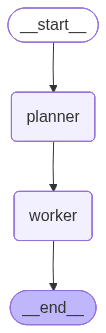

In [9]:
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display


# LangGraph 워크플로우 정의
workflow = StateGraph(AgentState)

# 노드 추가
workflow.add_node("planner", planner_node)
workflow.add_node("worker", worker_node)

# 엣지 연결: planner → worker → END
workflow.add_edge(START, "planner")
workflow.add_edge("planner", "worker")
workflow.add_edge("worker", END)

# 컴파일
app = workflow.compile()

print("LangGraph 워크플로우 구성 완료!")
print("흐름: planner → worker → END")

display(Image(app.get_graph().draw_mermaid_png()))

### Test: LangGraph Multi-Agent 실행

컴파일된 워크플로우를 실행하여 Planner → Worker 협업을 테스트합니다.

**확인 기준**:
- [ ] Planner가 3~5개의 명확한 Step을 생성했는가?
- [ ] Worker가 각 Step을 구체적인 정보로 실행했는가?
- [ ] State를 통해 plan이 Worker에게 전달되었는가?
- [ ] 단일 Agent 결과 대비 체계성이 향상되었는가?

**Agent 간 메시지 흐름 확인**:
```python
# messages 리스트에서 흐름 확인
for msg in result["messages"]:
    print(f"[{msg['sender']}] → [{msg['receiver']}]: {msg['task_type']}")
# 예상 출력:
# [Planner] → [Worker]: plan
# [Worker] → [User]: result
```

**체감 포인트**: "LangGraph로 계획과 실행을 분리하니 워크플로우가 명확하고 결과 품질도 높아졌네!"

In [10]:
# LangGraph 워크플로우 실행
def run_multi_agent(user_request: str) -> dict:
    """
    LangGraph Multi-Agent 시스템 실행
    
    Args:
        user_request: 사용자 요청
    
    Returns:
        최종 상태를 담은 딕셔너리
    """
    print("🚀 LangGraph Multi-Agent 시스템 시작\n")
    
    # 초기 상태 설정
    initial_state = {
        "user_request": user_request
    }
    
    # 워크플로우 실행
    print("📋 [Planner Agent] 계획 수립 중...")
    print("⚙️ [Worker Agent] 계획 실행 중...")
    
    final_state = app.invoke(initial_state)
    
    print("✅ 실행 완료\n")
    
    return final_state

# 테스트 실행
workflow_result = run_multi_agent("서울 2박3일 여행 계획 + 예산 50만원 이내")

print("=" * 50)
print("📊 최종 결과")
print("=" * 50)
print(workflow_result["result"])

🚀 LangGraph Multi-Agent 시스템 시작

📋 [Planner Agent] 계획 수립 중...
⚙️ [Worker Agent] 계획 실행 중...
✅ 실행 완료

📊 최종 결과
### Step 1: 여행 날짜 및 인원 수 결정하기
- **여행 날짜**: 2024년 5월 1일(수요일)부터 5월 3일(금요일)까지 2박 3일
- **인원 수**: 2명

### Step 2: 교통수단 선택하기
- **교통수단**: KTX (고속철도)
- **가격 조사**: 서울행 KTX 요금은 약 50,000원 (편도 기준)
- **총 교통비**: 왕복 2명 = 50,000원 x 2 x 2 = 200,000원

### Step 3: 숙소 예약하기
- **숙소 검색**: 에어비앤비에서 2박 3일 동안의 숙소를 검색
- **숙소 선택**: 홍대 근처의 1박 60,000원짜리 아파트를 예약
- **총 숙소비**: 60,000원 x 2 = 120,000원

### Step 4: 주요 관광지 목록 작성하기
- **관광지 선정**:
  1. 경복궁
  2. N서울타워
  3. 명동
  4. 홍대 거리
  5. 인사동

### Step 5: 관광지 입장료 및 운영 시간 확인하기
- **경복궁**: 입장료 3,000원, 운영시간 09:00 - 18:00
- **N서울타워**: 입장료 10,000원, 운영시간 10:00 - 23:00
- **명동**: 무료, 쇼핑 및 거리 음식
- **홍대 거리**: 무료, 카페 및 거리 공연
- **인사동**: 무료, 전통 문화 체험

### Step 6: 식사 장소 선정하기
- **식사 장소 조사**:
  1. **첫째 날 저녁**: 명동 교자 (칼국수) - 10,000원
  2. **둘째 날 아침**: 홍대 카페 (브런치) - 15,000원
  3. **둘째 날 점심**: 인사동 전통 음식점 - 12,000원
  4. **둘째 날 저녁**: 강남의 BBQ 치킨 - 20,000원
  5. **셋째 날 아침**: 숙소 근처 카페 - 10,000원



---

# Step 5: Reflection 패턴 추가

### Concept Check: Reflection 패턴이란?

**왜 이 단계가 필요한가요?**  
Planner-Worker만으로도 체계적인 결과를 얻을 수 있지만, 결과의 품질을 한 단계 더 높이려면 자기 검토가 필요합니다. Reflection 패턴은 "결과가 요청을 충족하는가?"를 스스로 평가하고 개선하는 **루프**입니다.

**Reflection 패턴**은 Agent가 자신의 결과를 검토하고 개선하는 자기 검토 루프입니다.

#### Reflection 루프 구조 (핵심)

```
[Planner] → [Worker] → [Reflection] ─── 품질 충분? ──→ [END]
                ↑                              │
                └──── 개선 필요 (재실행) ────────┘
```

**핵심 포인트**: Reflection은 단순 평가가 아니라 **평가→개선 루프**입니다.
- Reflection Agent가 결과를 검토하고 "충족/부분 충족/미충족"을 판정
- "부분 충족" 또는 "미충족"이면 개선된 결과를 만들어 Worker에게 다시 보냄
- 무한 루프 방지를 위해 `reflection_count`로 최대 반복 횟수를 제한 (예: 최대 1회)

#### Reflection Agent의 역할
- 결과가 원본 요청을 충족하는지 검토
- 누락된 정보나 개선 사항 식별
- **충족 시**: 최종 결과 확정 → END
- **미충족 시**: 개선 피드백을 result에 반영 → Worker 재실행

#### Agent 간 메시지 흐름 (Reflection 포함)
```
[Worker] State 쓰기: result = "Day 1: 경복궁..."
    ↓
[Reflection] State 읽기: user_request, plan, result
    ↓ LLM 호출 (검토)
[Reflection] 판정:
    충족 → State 쓰기: final_result = result → END
    부분 충족 → State 쓰기: result = "개선된 결과..." → Worker 재실행
```

### TODO 4: Reflection Agent 추가

- **요구사항**: Worker의 결과를 검토하고 개선 제안을 하는 Reflection Node를 구현합니다.
- **입력**: 
  - `state` (AgentState): 현재 상태 딕셔너리
    - `state["result"]` (str): Worker가 생성한 결과
    - `state["user_request"]` (str): 원본 사용자 요청
    - `state["plan"]` (str): Planner가 생성한 계획
- **출력**: 
  - `AgentState`: 업데이트된 상태 딕셔너리
    - `reflection` (str): 검토 결과 (충족 여부, 강점, 개선 필요)
    - `final_result` (str): 개선된 최종 결과
    - `messages` (List[dict]): 메시지 로그에 Reflection 결과 추가
- **예상 결과**: 
  - 검토 결과: "충족/부분 충족/미충족" 판정 + 구체적 피드백
  - 최종 결과: Worker 결과를 보완한 완성도 높은 결과물
- **확인 방법**: `print(reflection_state['reflection'][:800])`으로 검토 결과 확인
- **힌트**: 결과를 검토하고 누락된 부분이나 개선점을 제안합니다. 프롬프트에 "검토 항목"과 "출력 형식"을 명시하세요.

In [11]:
# TODO: Reflection Node 구현

MAX_REFLECTIONS = 1  # 최대 Reflection 반복 횟수 (무한 루프 방지)

def reflection_node(state: AgentState) -> AgentState:
    """
    Reflection Node: Worker의 결과를 검토하고 개선 제안을 합니다.
    
    Args:
        state: 현재 AgentState (result 포함)
    
    Returns:
        업데이트된 AgentState (reflection, final_result, reflection_count 필드 업데이트)
    """
    result = state["result"]
    user_request = state["user_request"]
    plan = state["plan"]
    count = state.get("reflection_count", 0)
    
    # Reflection 프롬프트
    reflection_prompt = f"""
당신은 결과를 검토하는 Reflection Agent입니다.

Worker Agent가 생성한 결과를 검토하고, 원본 요청을 충족하는지 평가하세요.

검토 항목:
1. 원본 요청의 모든 요구사항이 충족되었는가?
2. 누락된 정보가 있는가?
3. 정보의 정확성과 구체성은 적절한가?
4. 개선이 필요한 부분이 있는가?

---
원본 요청: {user_request}

실행된 계획:
{plan}

Worker의 결과:
{result}

---
위 내용을 검토하고 다음 형식으로 작성하세요:

## 검토 결과
- 충족 여부: [충족/부분 충족/미충족]
- 강점: [잘된 부분]
- 개선 필요: [부족한 부분]

## 최종 개선 결과
[Worker의 결과를 보완하여 최종 결과 작성]
"""
    
    # LLM 호출
    response = llm.invoke(reflection_prompt)
    reflection = response.content
    
    # 메시지 기록 추가
    messages = state.get("messages", [])
    messages.append({
        "sender": "Reflection",
        "receiver": "User",
        "content": reflection,
        "task_type": "reflection"
    })
    
    # State 업데이트하여 반환 (reflection_count 증가)
    return {
        **state,
        "reflection": reflection,
        "final_result": reflection,
        "reflection_count": count + 1,
        "messages": messages
    }

def should_continue_reflection(state: AgentState) -> str:
    """Reflection 후 종료할지 Worker로 돌아갈지 판단"""
    count = state.get("reflection_count", 0)
    reflection = state.get("reflection", "")
    
    # 최대 반복 횟수 초과 시 종료
    if count >= MAX_REFLECTIONS:
        return "end"
    
    # "충족" 판정이면 종료, 아니면 Worker로 재실행
    if "충족 여부: 충족" in reflection:
        return "end"
    
    return "worker"

# 테스트 (이전 worker_node 결과 사용)
reflection_state = reflection_node(final_state)

print("=== Reflection Node 결과 ===")
print(f"Reflection 횟수: {reflection_state['reflection_count']}")
print(f"검토 결과:\n{reflection_state['reflection'][:800]}...")

=== Reflection Node 결과 ===
Reflection 횟수: 1
검토 결과:
## 검토 결과
- 충족 여부: 부분 충족
- 강점: 여행 일정이 잘 구성되어 있으며, 주요 관광지와 맛집이 구체적으로 나열되어 있어 여행 계획에 유용하다. 예산 계획도 상세하게 작성되어 있어 비용을 미리 파악할 수 있다.
- 개선 필요: 숙소 예약에 대한 구체적인 정보가 부족하며, 각 관광지와 맛집의 위치 및 이동 경로에 대한 설명이 필요하다. 또한, 여행 준비물 체크리스트에 여권이 필요하다고 명시했으나, 국내 여행에서는 여권이 필요하지 않으므로 이를 수정해야 한다.

## 최종 개선 결과
### 3일 서울 여행 계획

#### Step 1: 여행 일정 설정
- **여행 날짜**: 2024년 5월 1일(수) ~ 2024년 5월 3일(금)
- **출발지**: 부산
- **도착지**: 서울
- **교통수단**: KTX를 이용하여 부산에서 서울로 이동 (소요 시간 약 2시간 30분)

#### Step 2: 관광지 목록 작성
1. **경복궁**: 조선 왕조의 대표적인 궁궐, 역사적인 건축물과 아름다운 정원.
2. **N서울타워**: 서울의 랜드마크로, 전망대에서 서울 전경을 감상할 수 있음.
3. **명동**: 쇼핑과 길거리 음식으로 유명한 번화가.
4. **홍대**: 젊은이들의 문화와 예술이 살아있는 지역, 다양한 카페와 클럽.
5. **북촌 한옥마을**: 전통 한옥이 잘 보존된 지역으로, 한국의 전통 문화를 체험할 수 있음.

#### Step 3: 맛집 목록 작성
1. **경복궁 근처**: 
   - **토속촌 삼계탕**: 전통 삼계탕 전문점.
2. **N서울타워 근처**: 
   - **N서울타워 레스토랑...


### TODO 5: 성과 평가 함수 구현

- **요구사항**: Multi-Agent 시스템의 결과를 평가하는 함수를 구현합니다.
- **입력**: 
  - `state` (AgentState): 현재 상태 딕셔너리 (user_request, plan, result, reflection 포함)
- **출력**: 
  - `dict`: 평가 결과
    - `score` (int): 종합 점수 (0~100)
    - `feedback` (str): 전체 피드백
    - `details` (dict): 세부 평가 항목별 점수
- **평가 항목**:
  - Planner 평가: 계획의 완성도, 단계 적절성 (0~30점)
  - Worker 평가: 실행 품질, 정보 충실도 (0~40점)
  - 전체 평가: 사용자 요청 충족도 (0~30점)
- **예상 결과**: 
  - 종합 점수: 70~90점 범위 (Reflection 적용 후 품질 향상)
  - JSON 출력 예시:
    ```json
    {
      "planner_score": 25,
      "worker_score": 35,
      "overall_score": 25,
      "feedback": "계획이 체계적이며, 대부분의 요청 사항을 충족함"
    }
    ```
- **확인 방법**: `print(f"종합 점수: {evaluation['score']}/100")`로 점수 출력
- **힌트**: LLM에게 평가 기준과 State 정보를 제공하여 점수와 피드백을 생성합니다. JSON 파싱 시 `re.search()`로 JSON 부분만 추출합니다.

In [12]:
# TODO: 성과 평가 함수 구현

import json
import re

def evaluate_multi_agent(state: AgentState) -> dict:
    """
    Multi-Agent 시스템의 성과를 평가합니다.

    Args:
        state: 현재 AgentState (user_request, plan, result, reflection 포함)

    Returns:
        dict: {"score": int, "feedback": str, "details": dict}
    """
    # 평가 프롬프트 구성
    eval_prompt = f"""
당신은 Multi-Agent 시스템의 성과를 평가하는 평가자입니다.

## 평가 기준
1. Planner 평가 (0~30점): 계획의 완성도, 단계 구성의 적절성
2. Worker 평가 (0~40점): 실행 품질, 정보의 충실도와 정확성
3. 전체 평가 (0~30점): 사용자 요청 충족도, 협업 효율성

## 입력 정보
- 사용자 요청: {state['user_request']}
- Planner의 계획: {state['plan']}
- Worker의 결과: {state['result']}
- Reflection 검토: {state.get('reflection', '없음')}

## 출력 형식
반드시 아래 JSON 형식만 출력하세요. 다른 텍스트는 포함하지 마세요.
{{"planner_score": <0~30>, "worker_score": <0~40>, "overall_score": <0~30>, "feedback": "<전체 피드백>"}}
"""

    response = llm.invoke(eval_prompt)
    content = response.content

    # JSON 파싱 (마크다운 코드 블록 처리)
    try:
        # 마크다운 코드 블록에서 JSON 추출 (```json ... ``` 또는 ``` ... ```)
        json_match = re.search(r'```(?:json)?\s*([\s\S]*?)\s*```', content)
        if json_match:
            json_str = json_match.group(1)
        else:
            # 코드 블록이 없으면 중괄호로 시작하는 JSON 추출
            json_match = re.search(r'\{[\s\S]*\}', content)
            json_str = json_match.group(0) if json_match else content

        result = json.loads(json_str)
        total_score = result['planner_score'] + result['worker_score'] + result['overall_score']
        return {
            "score": total_score,
            "feedback": result['feedback'],
            "details": {
                "planner": result['planner_score'],
                "worker": result['worker_score'],
                "overall": result['overall_score']
            }
        }
    except Exception as e:
        return {"score": 0, "feedback": f"평가 실패: {str(e)}", "details": {}}

# 테스트
evaluation = evaluate_multi_agent(reflection_state)
print("=== 성과 평가 결과 ===")
print(f"종합 점수: {evaluation['score']}/100")
print(f"세부 점수: Planner {evaluation['details'].get('planner', 0)}/30, Worker {evaluation['details'].get('worker', 0)}/40, 전체 {evaluation['details'].get('overall', 0)}/30")
print(f"피드백: {evaluation['feedback']}")

=== 성과 평가 결과 ===
종합 점수: 85/100
세부 점수: Planner 25/30, Worker 35/40, 전체 25/30
피드백: 여행 계획이 잘 구성되어 있으며, 주요 관광지와 맛집이 구체적으로 나열되어 있어 유용하다. 예산 계획도 상세하게 작성되어 있으나, 숙소 예약에 대한 구체적인 정보가 부족하고, 각 관광지와 맛집의 위치 및 이동 경로에 대한 설명이 필요하다. 여행 준비물 체크리스트에서 여권 대신 신분증으로 수정해야 한다.


### Guided Build: Reflection 패턴 워크플로우 구성

이제 Planner → Worker → Reflection 순서로 워크플로우를 구성합니다.
Reflection은 `should_continue_reflection` 함수로 **조건 분기**합니다:
- 품질 충분 또는 최대 반복 도달 → END
- 개선 필요 → Worker로 재실행

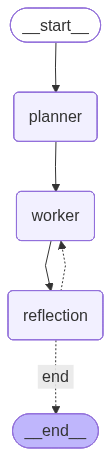

Reflection 패턴 워크플로우 구성 완료!
흐름: planner → worker → reflection → (조건 분기) → END 또는 worker


In [13]:
# Reflection 패턴 워크플로우 구성
workflow_reflection = StateGraph(AgentState)

# 노드 추가
workflow_reflection.add_node("planner", planner_node)
workflow_reflection.add_node("worker", worker_node)
workflow_reflection.add_node("reflection", reflection_node)

# 엣지 연결: planner → worker → reflection
workflow_reflection.add_edge(START, "planner")
workflow_reflection.add_edge("planner", "worker")
workflow_reflection.add_edge("worker", "reflection")

# Reflection 후 조건 분기: END 또는 Worker 재실행
workflow_reflection.add_conditional_edges(
    "reflection",
    should_continue_reflection,
    {"end": END, "worker": "worker"}
)

# 컴파일
app_reflection = workflow_reflection.compile()
display(Image(app_reflection.get_graph().draw_mermaid_png()))

print("Reflection 패턴 워크플로우 구성 완료!")
print("흐름: planner → worker → reflection → (조건 분기) → END 또는 worker")

In [14]:
# Reflection 패턴 워크플로우 실행
def run_multi_agent_reflection(user_request: str) -> dict:
    """
    Reflection 패턴이 포함된 Multi-Agent 시스템 실행
    
    Args:
        user_request: 사용자 요청
    
    Returns:
        최종 상태를 담은 딕셔너리
    """
    print("🚀 Reflection Multi-Agent 시스템 시작\n")
    
    # 초기 상태 설정
    initial_state = {
        "user_request": user_request
    }
    
    # 워크플로우 실행
    print("📋 [Planner Agent] 계획 수립 중...")
    print("⚙️ [Worker Agent] 계획 실행 중...")
    print("🔍 [Reflection Agent] 결과 검토 중...")
    
    final_state = app_reflection.invoke(initial_state)
    
    print(f"\n✅ 실행 완료 (Reflection 횟수: {final_state['reflection_count']})\n")
    
    return final_state

# 테스트 실행
reflection_result = run_multi_agent_reflection("서울 2박3일 여행 계획 + 예산 50만원 이내")

print("=" * 50)
print("📊 Reflection 최종 결과")
print("=" * 50)
print(reflection_result["final_result"])

🚀 Reflection Multi-Agent 시스템 시작

📋 [Planner Agent] 계획 수립 중...
⚙️ [Worker Agent] 계획 실행 중...
🔍 [Reflection Agent] 결과 검토 중...

✅ 실행 완료 (Reflection 횟수: 1)

📊 Reflection 최종 결과
## 검토 결과
- 충족 여부: 부분 충족
- 강점: 여행 일정이 잘 구성되어 있으며, 주요 관광지와 식사 계획이 포함되어 있어 여행의 흐름이 자연스럽습니다. 예산 내에서 교통비, 숙소, 관광지 입장료, 식사비를 잘 계산하였습니다.
- 개선 필요: 전체 예산이 50만원 이내로 설정되었으나, 식사비가 예상보다 높게 책정되었습니다. 또한, 교통비와 식사비의 세부 내역이 더 구체적이면 좋겠습니다. 비상시 연락처와 정보는 잘 정리되었으나, 추가적인 안전 정보나 여행 팁이 포함되면 더 유용할 것입니다.

## 최종 개선 결과
### Step 1: 여행 날짜 및 인원 수 결정하기
- **여행 날짜**: 2024년 5월 1일(수요일)부터 5월 3일(금요일)까지 2박 3일
- **인원 수**: 2명 (친구와 함께 여행)

### Step 2: 교통수단 선택하기
- **교통수단**: KTX (고속철도)
- **가격 조사**: 
  - 서울행 KTX 왕복 요금: 약 60,000원 (1인 기준)
  - 총 비용: 60,000원 x 2명 = 120,000원

### Step 3: 숙소 예약하기
- **숙소 검색**: 
  - 에어비앤비에서 서울 강남구에 위치한 2인용 스튜디오를 검색
  - 가격: 1박당 50,000원
  - 총 2박: 100,000원
- **예약 완료**: 에어비앤비에서 예약 완료

### Step 4: 주요 관광지 목록 작성하기
- **관광지 선정**:
  1. 경복궁
  2. N서울타워
  3. 명동
  4. 홍대
  5. 인사동

### Step 5: 관광지 입장료 및 교통비 예산 계산하기
- **입장료 조사**:
  - 경복궁: 3,000원 (1인)
  -

### Test: Reflection 패턴 실행 결과 확인

**확인 기준**:
- [ ] Reflection Agent가 Worker의 결과를 검토했는가?
- [ ] 충족 여부 판정이 이루어졌는가?
- [ ] 개선이 필요한 경우 Worker가 재실행되었는가?
- [ ] 최종 결과에 개선 내용이 반영되었는가?

**체감 포인트**: "Reflection Agent가 자동으로 결과를 검토하고 품질을 높여주니, 수동 검토 없이도 신뢰할 수 있는 결과를 얻을 수 있구나!"

---
## 트러블슈팅 가이드

실습/과제 진행 중 자주 발생하는 오류와 해결 방법입니다.

### API 관련

| 증상 | 원인 | 해결 방법 |
|------|------|----------|
| `AuthenticationError` | API Key 미설정 또는 잘못된 키 | `.env` 파일에 `OPENAI_API_KEY` 확인 |
| `RateLimitError` | API 호출 한도 초과 | 잠시 대기 후 재실행 (1~2분) |
| `InvalidRequestError` | 토큰 제한 초과 | 입력 텍스트 길이 줄이기 또는 청킹 크기 조정 |

### 패키지 관련

| 증상 | 원인 | 해결 방법 |
|------|------|----------|
| `ModuleNotFoundError` | 패키지 미설치 | Step 1의 `%pip install` 셀 재실행 |
| `ImportError: cannot import name` | 버전 불일치 | `%pip install --upgrade <패키지>` |
| ChromaDB `sqlite3` 오류 | SQLite 버전 낮음 | `%pip install pysqlite3-binary` 후 커널 재시작 |

### 일반

| 증상 | 원인 | 해결 방법 |
|------|------|----------|
| `NameError: name 'xxx' is not defined` | 이전 셀 미실행 | Step 1부터 순서대로 재실행 |
| 출력이 비어있음 | 환경 변수 로드 실패 | `.env` 파일 경로 확인 후 커널 재시작 |

---

## 실습 마무리

### 학습 내용 정리

이번 실습에서 배운 핵심 내용:

1. **단일 Agent의 한계**: 복잡한 작업에서 혼란, 누락, 품질 저하 발생
2. **Multi-Agent 대표 패턴**: Planner-Worker, Supervisor, Debate, Reflection, Hierarchical
3. **Planner-Worker 패턴**: 계획 수립과 실행을 분리하여 체계적 결과 도출
4. **Reflection 패턴**: 자기 검토 루프로 결과 품질 향상
5. **LangGraph StateGraph**: 상태 기반 워크플로우로 에이전트 간 협업 구현

### 학생용 자가 체크리스트

- [ ] 단일 Agent의 한계를 직접 체험했는가?
- [ ] Multi-Agent 대표 패턴 5가지를 설명할 수 있는가?
- [ ] LangGraph State를 정의하고 이해했는가?
- [ ] Planner Node가 계획을 수립하는 코드를 작성했는가?
- [ ] Worker Node가 계획을 실행하는 코드를 작성했는가?
- [ ] Reflection Node가 결과를 검토하고 개선하는 코드를 작성했는가?
- [ ] Reflection 패턴 전후 결과 품질 차이를 확인했는가?
- [ ] 성과 평가 함수로 결과 품질을 정량적으로 측정했는가?

---

### **Content License Agreement**

<font color='red'><b>**WARNING**</b></font> : 본 자료는 삼성 청년 SW아카데미의 컨텐츠 자산으로, 보안서약서에 의거하여 어떠한 사유로도 임의로 복사, 촬영, 녹음, 복제, 보관, 전송하거나 허가 받지 않은 저장매체를 이용한 보관, 제3자에게 누설, 공개 또는 사용하는 등의 무단 사용 및 불법 배포 시 법적 조치를 받을 수 있습니다.